In [ ]:
import pandas as pd # data analysis and manipulation
import numpy as np # maths equations
import plotly.graph_objects as go # for 3D visualization
import plotly.express as px # for 3D visualization
from scipy.stats import norm, skew # this tool is used for statistical analysis
# norm - stands for normal distribution (we will put this in histogram)
# skew - stands for skewness (This will be used in histogram only)
import seaborn as sns # (this is mixed of pandas and matplotlib)

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/wine-quality-dataset


In [ ]:
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/wine-quality-dataset


In [ ]:
df = pd.read_csv(f"{path}/WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
# Shows count of null values per column
print("1. Null values count per column:")
print(df.isnull().sum())

1. Null values count per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [ ]:
# Shows count of zero values per column
print("1. Zero values count per column:")
print((df == 0).sum())

1. Zero values count per column:
fixed acidity            0
volatile acidity         0
citric acid             99
residual sugar           0
chlorides                0
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       0
sulphates                0
alcohol                  0
quality                  0
Id                       1
dtype: int64


In [ ]:
#Selecting numeric columns for further processing
numeric_cols = df.select_dtypes(include='number').columns
print(numeric_cols)

#Selecting only the required columns for analysis
selected_cols = ['alcohol','quality','pH','citric acid','volatile acidity']

# Creating an analysis dataset
df_analysis = df[selected_cols]
print(f"\nSelected columns for histograms & boxplots:")
print(df_analysis.columns.tolist())

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

Selected columns for histograms & boxplots:
['alcohol', 'quality', 'pH', 'citric acid', 'volatile acidity']


## Histogram

In [ ]:
# to find range we use for loop (we know there are 4 indexes) , if we don't know use while loop
for col in selected_cols:  # value will be printed one by one as they are called
  x = df[col]     # small x is variable
  mean, std = x.mean(), x.std() # Z-score requirements

 # plotting histogram with density curve # opacity - how much to display
  hist = go.Histogram(x = x, histnorm = 'probability density', name = "histogram" , opacity = 0.6 )

# Creating normal distribution curve
  x_range = np.linspace(x.min(), x.max(), 100)
  normal_curve = go.Scatter(x = x_range, y=norm.pdf(x_range, mean, std), mode = 'lines', name = 'Normal Distribution' )

#Setting the layout
  layout = go.Layout(
      title = f'{col.capitalize()} Distribution<br>Skewness = {x.skew():.2f}',
      xaxis_title = col,
      yaxis_title = 'Density',
      bargap = 0.2
  )

# Plotting the figure
  fig = go.Figure(data = [hist, normal_curve], layout = layout)
  fig.show()

# Correlation Matrix

In [ ]:
corr_matrix = df[selected_cols].corr()
corr_matrix

,alcohol,quality,pH,citric acid,volatile acidity
alcohol,1.000000,0.484866,0.225322,0.106250,-0.203909
quality,0.484866,1.000000,-0.052453,0.240821,-0.407394
pH,0.225322,-0.052453,1.000000,-0.546339,0.221492
citric acid,0.106250,0.240821,-0.546339,1.000000,-0.544187
volatile acidity,-0.203909,-0.407394,0.221492,-0.544187,1.000000


In [ ]:
fig = px.imshow(
    corr_matrix,
    text_auto = True,
    color_continuous_scale = 'RdBu_r',
    title = "Correlation Matrix of Numerical Features",
    aspect = "auto"
)
fig.update_layout(margin = dict(l = 60, r = 60, t = 50, b = 50))
fig.show()

## Box Plot

In [ ]:
categorical_cols = 'quality'

for col in selected_cols:
  fig = px.box(df, x = categorical_cols, y = col, points = 'all' ,color = categorical_cols,
               title = f'{col.capitalize()} Box Plot grouped by {categorical_cols.capitalize()}',
               notched = True)
  fig.update_layout(yaxis_title=col, xaxis_title = categorical_cols)
  fig.show()

# Linear Regression Model

In [ ]:
!pip install statsmodels

In [ ]:
import statsmodels.api as sm
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [ ]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("yasserh/wine-quality-dataset")
df = pd.read_csv(f"{path}/WineQT.csv")

# Selecting numeric columns for further processing
numeric_cols = df.select_dtypes(include='number').columns
print(numeric_cols)

# Selecting only the required columns for analysis
selected_cols = ['alcohol','quality','pH','citric acid','volatile acidity']

# Creating an analysis dataset
df_analysis = df[selected_cols]
print(f"\nSelected columns:")
print(df_analysis.columns.tolist())

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

Selected columns:
['alcohol', 'quality', 'pH', 'citric acid', 'volatile acidity']


In [ ]:
# Prepare features (X) and target (y)
X = df_analysis.drop('quality', axis=1)
y = df_analysis['quality']

In [ ]:
X.head(1)

,alcohol,pH,citric acid,volatile acidity
0,9.4,3.51,0.0,0.7


In [ ]:
y.head(1)

,quality
0,5


In [ ]:
# Adding constant for intercept (required for OLS)
X_with_constant = sm.add_constant(X)

# Fiting OLS model
ols_model = sm.OLS(y, X_with_constant).fit()

# Displaying the OLS summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     147.5
Date:                Tue, 10 Jun 2025   Prob (F-statistic):          1.18e-101
Time:                        14:42:16   Log-Likelihood:                -1135.9
No. Observations:                1143   AIC:                             2282.
Df Residuals:                    1138   BIC:                             2307.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                4.6817      0.528  

# Model Evaluation

In [ ]:
# Predictions
y_pred = ols_model.predict(X_with_constant)

# R-squared
r_squared = ols_model.rsquared

# MAE
mae = mean_absolute_error(y, y_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R-squared: {r_squared:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R-squared: 0.3414
MAE: 0.5161
RMSE: 0.6537


## Visualization of Model Assumptions and Performance

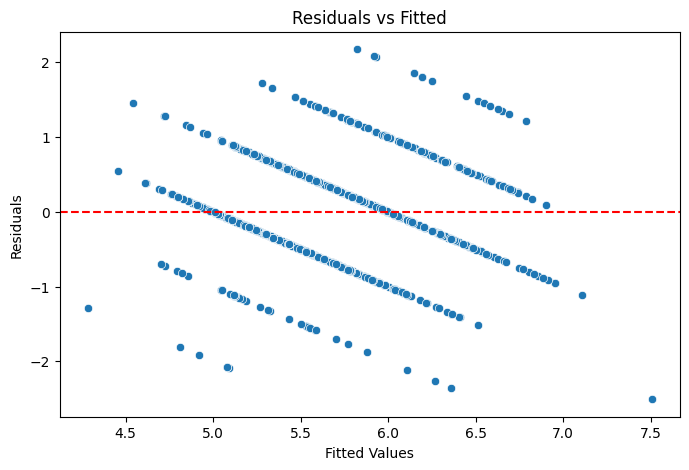

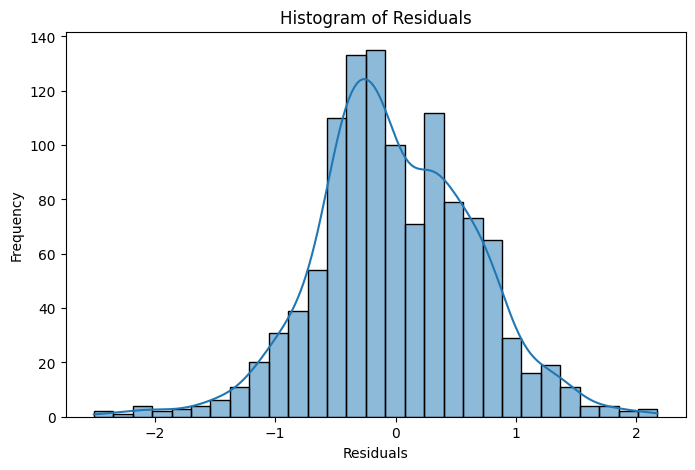

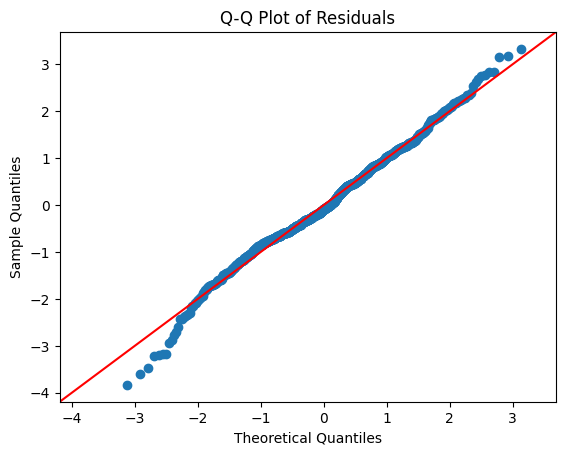

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Residuals
residuals = y - y_pred

# Residual vs Fitted plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# Histogram of residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# Q-Q plot for normality
import scipy.stats as stats
import statsmodels.api as sm

sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()